# Derivation of the Boundary Flux Coefficient

Mohammad's implementation is based on deriving an equivalent **boundary face flux** from the Robin boundary condition.

## Step 1: Robin Boundary Condition

The prescribed Robin boundary condition is

$$
J = p - \frac{1}{v}\frac{dp}{dx} = 0
$$

Rearranging,

$$
\frac{dp}{dx}=vp
$$

At the boundary face,

$$
\left.\frac{dp}{dx}\right|_f = vp_f.
$$

---

## Step 2: Relate the Face Value to the Cell Value

In the finite-volume method, the unknown is stored at the **cell center**, while the boundary condition is applied at the **boundary face**.

```
Last Cell Center                Boundary Face
      P ----------------------| f
             Δx/2
```

The distance between the last cell center and the boundary face is

$$
d=\frac{\Delta x}{2}.
$$

Using a first-order Taylor expansion,

$$
p_f = p_P + d\left.\frac{dp}{dx}\right|_f
$$

or

$$
p_f = p_P + \frac{\Delta x}{2}\left.\frac{dp}{dx}\right|_f.
$$

---

## Step 3: Apply the Robin Boundary Condition

Since

$$
\left.\frac{dp}{dx}\right|_f = vp_f,
$$

substitute into the Taylor expansion:

$$
p_f = p_P + \frac{v\Delta x}{2}p_f.
$$

Rearrange,

$$
p_f\left(1-\frac{v\Delta x}{2}\right)=p_P.
$$

Therefore,

$$
\boxed{
p_f=\frac{p_P}{1-v\Delta x/2}
}
$$

---

## Step 4: Compute the Boundary Flux

The governing equation

$$
\frac{d^2p}{dx^2}+v\frac{dp}{dx}=0
$$

can be written in conservative form as

$$
\frac{d}{dx}\left(\frac{dp}{dx}+vp\right)=0.
$$

Hence, the conservative flux is

$$
F=\frac{dp}{dx}+vp.
$$

Using the Robin boundary condition,

$$
\frac{dp}{dx}=vp,
$$

the boundary flux becomes

$$
F_f = vp_f + vp_f = 2vp_f.
$$

Substituting the reconstructed face value,

$$
F_f
=
2v
\left(
\frac{p_P}{1-v\Delta x/2}
\right).
$$

Therefore,

$$
\boxed{
F_f
=
\frac{2v}{1-v\Delta x/2}p_P
}
$$

This is exactly the coefficient used in the FiPy implementation:

```python
d = dx / 2

fluxCoeff.setValue(
    (2*v/(1-v*d),),
    where=mesh.facesRight
)
```

---

## Summary

The coefficient

$$
\frac{2v}{1-v\Delta x/2}
$$

is obtained by combining:

1. The Robin boundary condition
   $$\frac{dp}{dx}=vp$$

2. A first-order Taylor expansion from the cell center to the boundary face.

3. The conservative flux definition

   $$
   F=\frac{dp}{dx}+vp.
   $$

This reconstructed boundary flux is then supplied to FiPy through a `FaceVariable`, allowing the Robin boundary condition to be implemented without manually assembling the system matrix.

v            : 1.0
Maximum Error: 9.13561912e-05
L2 Error     : 5.91625394e-05


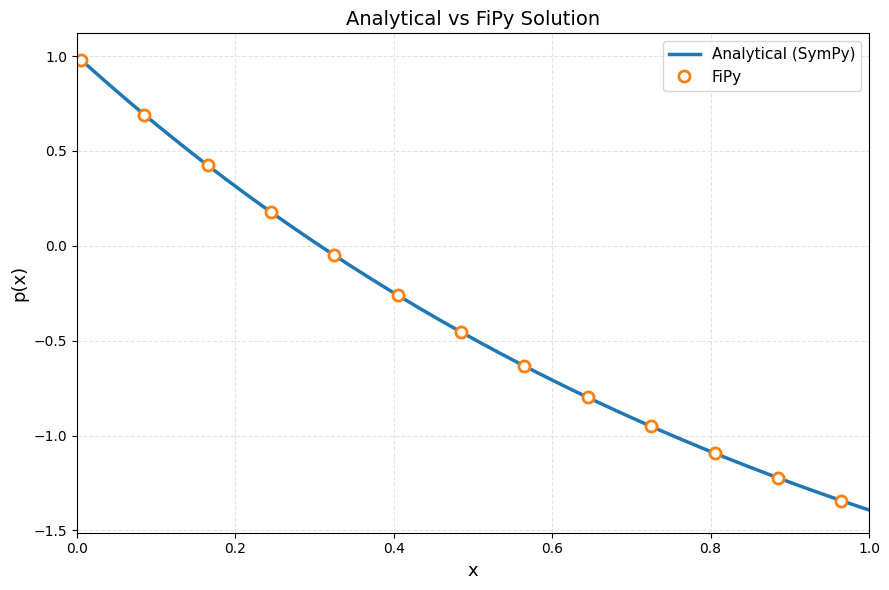

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from fipy import (
    CellVariable,
    FaceVariable,
    Grid1D,
    DiffusionTerm,
    PowerLawConvectionTerm,
)

# ==========================================================
# PARAMETERS
# ==========================================================

v = 1.0          # Drift velocity
L = 1.0
nx = 100
dx = L / nx

# ==========================================================
# MESH
# ==========================================================

mesh = Grid1D(nx=nx, dx=dx)

# ==========================================================
# UNKNOWN VARIABLE
# ==========================================================

p = CellVariable(mesh=mesh, name="p")

# ==========================================================
# LEFT DIRICHLET BC
# p(0) = 1
# ==========================================================

p.constrain(1.0, mesh.facesLeft)

# ==========================================================
# ROBIN BC (Mohammad's Method)
# ==========================================================

# Suppress FiPy's default diffusive contribution
p.faceGrad.constrain((0.,), mesh.facesRight)

d = dx / 2.0

fluxCoeff = FaceVariable(
    mesh=mesh,
    rank=1,
    value=(v,)
)

# Modify only the right boundary face
fluxCoeff.setValue(
    (2.0 * v / (1.0 - v * d),),
    where=mesh.facesRight
)

# ==========================================================
# EQUATION
# ==========================================================

eq = (
    DiffusionTerm(coeff=1.0)
    + PowerLawConvectionTerm(coeff=fluxCoeff)
)

eq.solve(var=p)

# ==========================================================
# CELL CENTERS
# ==========================================================

x = mesh.cellCenters[0].value

# ==========================================================
# EXACT ANALYTICAL SOLUTION
# p(x) = (exp(-vx)-2exp(-v))/(1-2exp(-v))
# ==========================================================

exact = (
    np.exp(-v * x)
    - 2.0 * np.exp(-v)
) / (
    1.0
    - 2.0 * np.exp(-v)
)

# ==========================================================
# ERROR
# ==========================================================

max_error = np.max(np.abs(p.value - exact))
l2_error = np.sqrt(np.mean((p.value - exact) ** 2))

print("=" * 60)
print(f"v            : {v}")
print(f"Maximum Error: {max_error:.8e}")
print(f"L2 Error     : {l2_error:.8e}")
print("=" * 60)

# ==========================================================
# PLOT
# ==========================================================

xx = np.linspace(0, L, 500)

exact_plot = (
    np.exp(-v * xx)
    - 2.0 * np.exp(-v)
) / (
    1.0
    - 2.0 * np.exp(-v)
)

plt.figure(figsize=(9, 6))

# ----------------------------------------------------------
# Analytical (SymPy)
# ----------------------------------------------------------

plt.plot(
    xx,
    exact_plot,
    color='tab:blue',
    linewidth=2.5,
    label='Analytical (SymPy)'
)

# ----------------------------------------------------------
# FiPy (Open-circle markers only)
# ----------------------------------------------------------

skip = 8  # Show every 8th numerical point

plt.plot(
    x[::skip],
    p.value[::skip],
    linestyle='None',
    marker='o',
    markersize=8,
    markerfacecolor='white',
    markeredgecolor='tab:orange',
    markeredgewidth=2,
    label='FiPy'
)

# ==========================================================
# FIGURE FORMATTING
# ==========================================================

plt.xlabel("x", fontsize=13)
plt.ylabel("p(x)", fontsize=13)
plt.title("Analytical vs FiPy Solution", fontsize=14)

plt.xlim(0, 1)
plt.grid(True, linestyle='--', alpha=0.35)

plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

# Derivation of the Boundary Flux Coefficient (Left Robin Boundary)

Mohammad's implementation is based on deriving an equivalent **boundary face flux** from the Robin boundary condition.

## Step 1: Robin Boundary Condition

The prescribed Robin boundary condition is

$$
J = p - \frac{1}{v}\frac{dp}{dx} = 0
$$

Rearranging,

$$
\frac{dp}{dx}=vp.
$$

At the boundary face,

$$
\left.\frac{dp}{dx}\right|_f = vp_f.
$$

---

## Step 2: Relate the Face Value to the Cell Value

In the finite-volume method, the unknown is stored at the **cell center**, while the boundary condition is applied at the **boundary face**.

```text
Boundary Face              First Cell Center
      f |---------------------- P
               Δx/2
```

The distance between the boundary face and the first cell center is

$$
d=\frac{\Delta x}{2}.
$$

Since the face lies **to the left** of the cell center, the first-order Taylor expansion becomes

$$
p_f = p_P - d\left.\frac{dp}{dx}\right|_f
$$

or

$$
p_f = p_P - \frac{\Delta x}{2}\left.\frac{dp}{dx}\right|_f.
$$

---

## Step 3: Apply the Robin Boundary Condition

Since

$$
\left.\frac{dp}{dx}\right|_f = vp_f,
$$

substitute into the Taylor expansion:

$$
p_f = p_P - \frac{v\Delta x}{2}p_f.
$$

Rearrange,

$$
p_f\left(1+\frac{v\Delta x}{2}\right)=p_P.
$$

Therefore,

$$
\boxed{
p_f=\frac{p_P}{1+v\Delta x/2}
}
$$

---

## Step 4: Compute the Boundary Flux

The governing equation

$$
\frac{d^2p}{dx^2}+v\frac{dp}{dx}=0
$$

can be written in conservative form as

$$
\frac{d}{dx}\left(\frac{dp}{dx}+vp\right)=0.
$$

Hence, the conservative flux is

$$
F=\frac{dp}{dx}+vp.
$$

Using the Robin boundary condition,

$$
\frac{dp}{dx}=vp,
$$

the boundary flux becomes

$$
F_f = vp_f + vp_f = 2vp_f.
$$

Substituting the reconstructed face value,

$$
F_f
=
2v
\left(
\frac{p_P}{1+v\Delta x/2}
\right).
$$

Therefore,

$$
\boxed{
F_f
=
\frac{2v}{1+v\Delta x/2}p_P
}
$$

This is exactly the coefficient used in the FiPy implementation:

```python
d = dx / 2

fluxCoeff.setValue(
    (2*v/(1+v*d),),
    where=mesh.facesLeft
)
```

---

## Summary

The coefficient

$$
\frac{2v}{1+v\Delta x/2}
$$

is obtained by combining:

1. The Robin boundary condition

   $$
   \frac{dp}{dx}=vp
   $$

2. A first-order Taylor expansion from the cell center to the boundary face.

3. The conservative flux definition

   $$
   F=\frac{dp}{dx}+vp.
   $$

This reconstructed boundary flux is then supplied to FiPy through a `FaceVariable`, allowing the Robin boundary condition to be implemented without manually assembling the system matrix.

---

The only mathematical difference compared to the **right Robin boundary** is the sign in the Taylor expansion. Since the boundary face is located to the **left** of the cell center, the Taylor expansion uses a **minus** sign, leading to

$$
1-\frac{v\Delta x}{2}
\quad\longrightarrow\quad
1+\frac{v\Delta x}{2},
$$

and consequently the left-boundary coefficient becomes

$$
\boxed{
\frac{2v}{1+v\Delta x/2}
}.
$$

LEFT ROBIN / RIGHT DIRICHLET
Maximum Error : 6.13322233e-06
L2 Error      : 3.08935281e-06


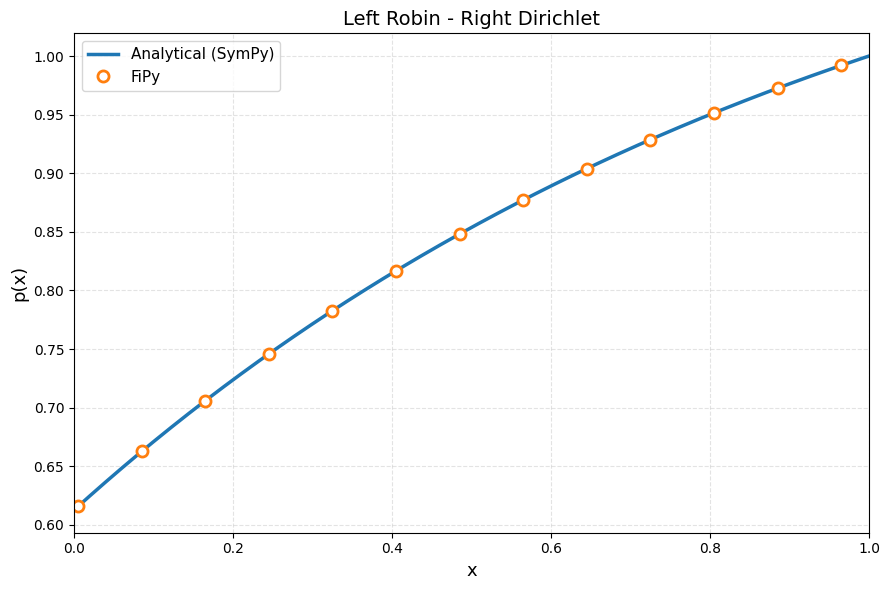

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from fipy import (
    CellVariable,
    FaceVariable,
    Grid1D,
    DiffusionTerm,
    PowerLawConvectionTerm,
)

# ==========================================================
# PARAMETERS
# ==========================================================

v = 1.0
L = 1.0
nx = 100
dx = L / nx

# ==========================================================
# MESH
# ==========================================================

mesh = Grid1D(nx=nx, dx=dx)

# ==========================================================
# UNKNOWN
# ==========================================================

p = CellVariable(mesh=mesh, name="p")

# ==========================================================
# RIGHT DIRICHLET
# ==========================================================

p.constrain(1.0, mesh.facesRight)

# ==========================================================
# LEFT ROBIN (Mirror of Mohammad's Method)
# ==========================================================

# Disable FiPy's native left diffusive contribution
p.faceGrad.constrain((0.,), mesh.facesLeft)

d = dx / 2.0

fluxCoeff = FaceVariable(
    mesh=mesh,
    rank=1,
    value=(v,)
)

# Modify ONLY the LEFT boundary face
fluxCoeff.setValue(
    (2.0 * v / (1.0 + v * d),),
    where=mesh.facesLeft
)

# ==========================================================
# EQUATION
# ==========================================================

eq = (
    DiffusionTerm(coeff=1.0)
    + PowerLawConvectionTerm(coeff=fluxCoeff)
)

eq.solve(var=p)

# ==========================================================
# CELL CENTERS
# ==========================================================

x = mesh.cellCenters[0].value

# ==========================================================
# ANALYTICAL SOLUTION
#
# p(1)=1
# p-(1/v)dp/dx=0 at x=0
# ==========================================================

exact = (
    np.exp(-v * x)
    - 2.0
) / (
    np.exp(-v)
    - 2.0
)

# ==========================================================
# ERRORS
# ==========================================================

max_error = np.max(np.abs(p.value - exact))
l2_error = np.sqrt(np.mean((p.value - exact) ** 2))

print("=" * 60)
print("LEFT ROBIN / RIGHT DIRICHLET")
print(f"Maximum Error : {max_error:.8e}")
print(f"L2 Error      : {l2_error:.8e}")
print("=" * 60)

# ==========================================================
# PLOT
# ==========================================================

xx = np.linspace(0, L, 500)

exact_plot = (
    np.exp(-v * xx)
    - 2.0
) / (
    np.exp(-v)
    - 2.0
)

plt.figure(figsize=(9, 6))

# ----------------------------------------------------------
# Analytical (SymPy)
# ----------------------------------------------------------

plt.plot(
    xx,
    exact_plot,
    color='tab:blue',
    linewidth=2.5,
    label='Analytical (SymPy)'
)

# ----------------------------------------------------------
# FiPy (Open-circle markers only)
# ----------------------------------------------------------

skip = 8  # Show every 8th numerical point

plt.plot(
    x[::skip],
    p.value[::skip],
    linestyle='None',
    marker='o',
    markersize=8,
    markerfacecolor='white',
    markeredgecolor='tab:orange',
    markeredgewidth=2,
    label='FiPy'
)

# ==========================================================
# FIGURE FORMATTING
# ==========================================================

plt.xlabel("x", fontsize=13)
plt.ylabel("p(x)", fontsize=13)
plt.title("Left Robin - Right Dirichlet", fontsize=14)

plt.xlim(0, 1)
plt.grid(True, linestyle='--', alpha=0.35)

plt.legend(fontsize=11)
plt.tight_layout()

plt.show()